# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**ResNet-18 Models Notebook**

**Description:** This is the Jupyter Notebook training and evaluating a ResNet-18 model on the Pneumonia dataset without data augmentation.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [ ]:
# Import utility libraries (calculations, data manipulation, visualization)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Import deep learning libraries - tensorflow
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import to_categorical

# Import metrics libraries
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Data Loading & Preprocessing

## Load the data

In [17]:
# Load the data
data_path = "../data/"
train_images = np.load(data_path + "train_images.npy")
train_labels = np.load(data_path + "train_labels.npy")
test_images = np.load(data_path + "test_images.npy")
test_labels = np.load(data_path + "test_labels.npy")
val_images = np.load(data_path + "val_images.npy")
val_labels = np.load(data_path + "val_labels.npy")

print("Original shapes:")
print("Train - images:", train_images.shape, " labels:", train_labels.shape)
print("Val   - images:", val_images.shape, " labels:", val_labels.shape)
print("Test  - images:", test_images.shape, " labels:", test_labels.shape)

Original shapes:
Train - images: (4708, 28, 28)  labels: (4708, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)


## Preprocess the data

In [18]:
# Preprocess data for ResNet
def preprocess_data(images, labels):
    # Reshape to include channel dimension (grayscale = 1 channel)
    images = images.reshape(images.shape[0], 28, 28, 1)
    
    # Normalize pixel values
    images = images.astype('float32') / 255.0
    
    # Convert labels to one-hot encoding
    labels = to_categorical(labels, 2)
    
    return images, labels

# Apply preprocessing to all datasets
train_images, train_labels = preprocess_data(train_images, train_labels)
val_images, val_labels = preprocess_data(val_images, val_labels)
test_images, test_labels = preprocess_data(test_images, test_labels)

print("\nAfter preprocessing:")
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Val images shape:", val_images.shape)
print("Val labels shape:", val_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)


After preprocessing:
Train images shape: (4708, 28, 28, 1)
Train labels shape: (4708, 2)
Val images shape: (524, 28, 28, 1)
Val labels shape: (524, 2)
Test images shape: (624, 28, 28, 1)
Test labels shape: (624, 2)


# ResNet-18 Model

## Model Architecture

### Residual Block

In [4]:
def residual_block(x, filters, kernel_size=3, stride=1, use_bias=True, name=None):
    """
    A residual block for ResNet18
    """
    shortcut = x
    
    # First convolutional layer
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', use_bias=use_bias, name=f"{name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation('relu', name=f"{name}_relu1")(x)
    
    # Second convolutional layer
    x = layers.Conv2D(filters, kernel_size, padding='same', use_bias=use_bias, name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    
    # If stride > 1 or channels changed, we need to downsample the shortcut connection
    if stride > 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=use_bias, name=f"{name}_shortcut_conv")(shortcut)
        shortcut = layers.BatchNormalization(name=f"{name}_shortcut_bn")(shortcut)
    
    # Add shortcut to main path
    x = layers.Add(name=f"{name}_add")([x, shortcut])
    x = layers.Activation('relu', name=f"{name}_relu2")(x)
    return x

### Build the Model

In [5]:
def build_resnet18(input_shape=(28, 28, 1), num_classes=2, dropout_rate=0.3):
    """
    Build a ResNet-18 model adapted for small input size (28x28) with dropout
    """
    inputs = layers.Input(shape=input_shape)
    
    # Initial convolution - reduced kernel and stride due to small input size
    x = layers.Conv2D(64, 3, strides=1, padding='same', use_bias=True, name="conv1")(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Activation('relu', name="relu1")(x)
    x = layers.MaxPooling2D(2, strides=2, padding='same', name="maxpool1")(x)
    
    # ResNet blocks
    # Stage 1
    x = residual_block(x, 64, name="stage1_block1")
    x = residual_block(x, 64, name="stage1_block2")
    
    # Stage 2
    x = residual_block(x, 128, stride=2, name="stage2_block1")
    x = residual_block(x, 128, name="stage2_block2")
    
    # Stage 3
    x = residual_block(x, 256, stride=2, name="stage3_block1")
    x = residual_block(x, 256, name="stage3_block2")
    
    # Stage 4
    x = residual_block(x, 512, stride=2, name="stage4_block1")
    x = residual_block(x, 512, name="stage4_block2")
    
    # Final layers
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)  # Add dropout layer
    outputs = layers.Dense(num_classes, activation='softmax', name="fc")(x)
    
    model = models.Model(inputs, outputs)
    return model

### Create & Compile Model

In [6]:
# Create the model
resnet18 = build_resnet18(dropout_rate=0.3)

# Model architecture summary
resnet18.summary()

# Compile the model
resnet18.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'AUC']
)

I0000 00:00:1741874010.720752  166175 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2787 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 28, 28,    │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 28, 28,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 28, 28,    │          0 │ bn1[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool1            │ (None, 14, 14,    │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 14, 14,    │     36,928 │ maxpool1[0][0]    │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 14, 14,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 14, 14,    │     36,928 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 14, 14,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 64)               │            │ maxpool1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu2 │ (None, 14, 14,    │          0 │ stage1_block1_ad… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv1 │ (None, 14, 14,    │     36,928 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn1   │ (None, 14, 14,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_relu1 │ (None, 14, 14,    │          0 │ stage1_block2_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv2 │ (None, 14, 14,    │     36,928 │ stage1_block2_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn2   │ (None, 14, 14,    │        256 │ stage1_block2_co

 Total params: 11,183,106 (42.66 MB)

 Trainable params: 11,173,506 (42.62 MB)

 Non-trainable params: 9,600 (37.50 KB)

# Callback Definition

In [7]:
# Define callbacks
checkpoint_callback = callbacks.ModelCheckpoint(
    '../models/resnet18_best_model.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

early_stop_callback = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

reduce_lr_callback = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5
)

# List of all callbacks
all_callbacks = [
    checkpoint_callback,
    early_stop_callback,
    reduce_lr_callback
]

## Dropout Rate Scheduler Callback

In [8]:
class DropoutRateScheduler(callbacks.Callback):
    """Custom callback to adjust dropout rate during training"""
    
    def __init__(self, dropout_start=0.5, dropout_end=0.3, epochs=50):
        super().__init__()
        self.dropout_start = dropout_start
        self.dropout_end = dropout_end
        self.epochs = epochs
    
    def on_epoch_begin(self, epoch, logs=None):
        # Linear decay of dropout rate
        decay_rate = (self.dropout_start - self.dropout_end) / self.epochs
        new_dropout = self.dropout_start - decay_rate * epoch
        
        # Set the dropout rate for the dropout layer
        self.model.get_layer('dropout').rate = max(new_dropout, self.dropout_end)
        print(f"Epoch {epoch+1}: dropout rate set to {self.model.get_layer('dropout').rate:.4f}")

# Add to callbacks list
dropout_scheduler = DropoutRateScheduler(dropout_start=0.5, dropout_end=0.3, epochs=50)
all_callbacks.append(dropout_scheduler)

# Model Training and Evaluation

## Train the Model

In [9]:
# Train the model
history = resnet18.fit(
    train_images,
    train_labels,
    batch_size=32,
    epochs=50,
    validation_data=(val_images, val_labels),
    callbacks=all_callbacks
)

Epoch 1: dropout rate set to 0.5000
Epoch 1/50


I0000 00:00:1741874019.621376  166249 service.cc:148] XLA service 0x754364044f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1741874019.621390  166249 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti with Max-Q Design, Compute Capability 7.5
2025-03-13 13:53:39.848492: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1741874020.951995  166249 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-03-13 13:53:41.730080: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[32,64,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,14,14]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"c

  2/148 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - AUC: 0.5863 - accuracy: 0.5000 - loss: 1.0840  

I0000 00:00:1741874029.105375  166249 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


146/148 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - AUC: 0.9436 - accuracy: 0.8828 - loss: 0.3831

2025-03-13 13:53:57.166760: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[4,64,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,64,14,14]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-13 13:53:57.260463: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[4,128,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,128,7,7]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationFo

148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - AUC: 0.9439 - accuracy: 0.8833 - loss: 0.3814

2025-03-13 13:54:05.942217: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[12,64,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,64,14,14]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-13 13:54:06.059269: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[12,128,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,128,7,7]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivati

148/148 ━━━━━━━━━━━━━━━━━━━━ 37s 130ms/step - AUC: 0.9441 - accuracy: 0.8836 - loss: 0.3805 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 3.2120 - learning_rate: 0.0010
Epoch 2: dropout rate set to 0.4960
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - AUC: 0.9833 - accuracy: 0.9423 - loss: 0.1662 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 3.6565 - learning_rate: 0.0010
Epoch 3: dropout rate set to 0.4920
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - AUC: 0.9931 - accuracy: 0.9605 - loss: 0.1011 - val_AUC: 0.7495 - val_accuracy: 0.7424 - val_loss: 2.5359 - learning_rate: 0.0010
Epoch 4: dropout rate set to 0.4880
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - AUC: 0.9955 - accuracy: 0.9718 - loss: 0.0740 - val_AUC: 0.9946 - val_accuracy: 0.9580 - val_loss: 0.0959 - learning_rate: 0.0010
Epoch 5: dropout rate set to 0.4840
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - AUC: 0.9973 - accuracy: 0.9785 - loss: 0.0594 - val_AUC: 0.9955 - val_

## Evaluate the Model

In [10]:
# Evaluate the model on test data
test_loss, test_accuracy, test_auc = resnet18.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test AUC: {test_auc:.4f}")

14/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.8831 - accuracy: 0.8592 - loss: 1.2740

2025-03-13 13:57:01.937430: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,64,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,14,14]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-13 13:57:02.054891: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,128,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,7,7]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivati

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - AUC: 0.8882 - accuracy: 0.8593 - loss: 1.2033
Test accuracy: 0.8574
Test loss: 1.0729
Test AUC: 0.8960


# Results

## Visualize Training History

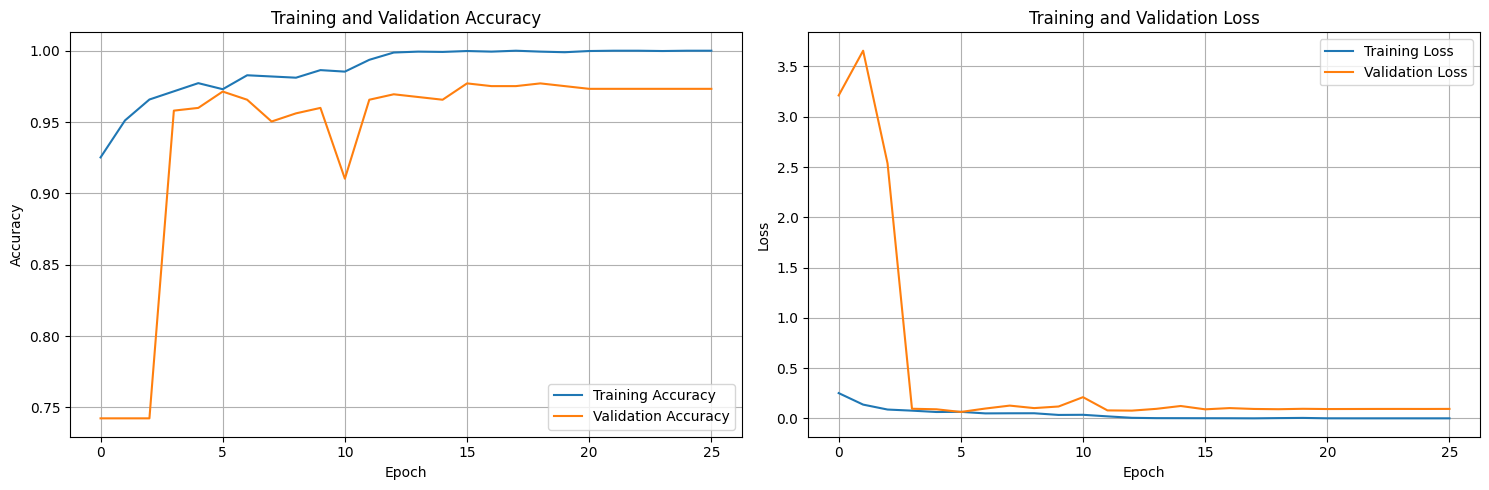

In [11]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Training and Validation Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Loss plot
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Training and Validation Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)


## Classification Metrics and ROC Curve

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step


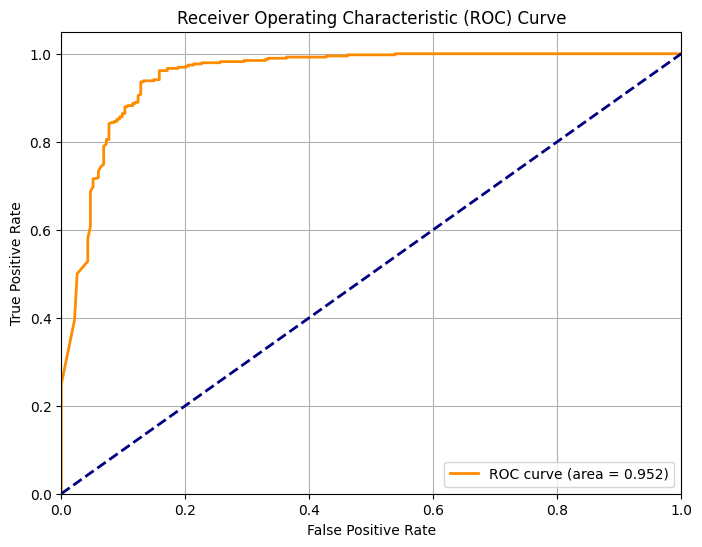

ROC AUC Score: 0.9518


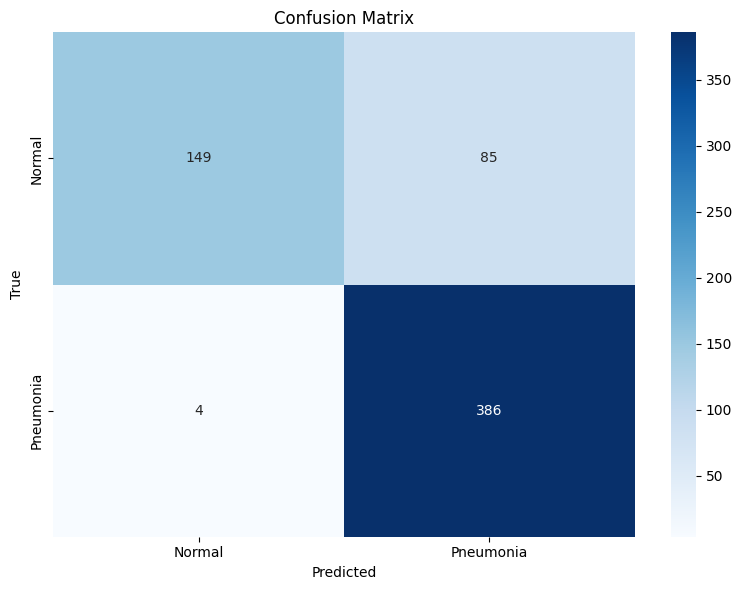

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.64      0.77       234
   Pneumonia       0.82      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.90      0.81      0.83       624
weighted avg       0.88      0.86      0.85       624



In [12]:
# Make predictions on test data
predictions = resnet18.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(test_labels[:, 1], predictions[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Print AUC score
print(f"ROC AUC Score: {roc_auc:.4f}")

# Confusion matrix and classification report (existing code)
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Pneumonia'], 
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=['Normal', 'Pneumonia']))

## Save the Model

In [ ]:
# Save the model in the newer .keras format
model_path = "../models/"
model_name = "resnet18_pneumonia_model.keras"
resnet18.save(model_path + model_name)
print("Model saved successfully at:", model_path + model_name)

Model saved successfully at: ../models/resnet18_pneumonia_model.keras
